# Como usar BrainOmni

## 1. Preparando ambiente

### Criar um ambiente virtual

```
 Com conda (recomendado)
conda create -n brainomni python=3.10.14
conda activate brainomni

# Ou com venv
python3.10 -m venv brainomni_env
source brainomni_env/bin/activate  # Linux/Mac
# brainomni_env\Scripts\activate   # Windows
```

### Instalar as dependências

Atualizar pip e instalar packaging.

```
pip install --upgrade pip setuptools wheel packaging
```

Instalar o PyTorch primeiro.

```
pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124
```

Isso instala o PyTorch com suporte a CUDA 12.4, que é o que o projeto usa.

Agora, precisamos baixar o CUDA Toolkit. Ele compila código CUDA.

```
sudo apt install nvidia-cuda-toolkit
```

Depois, instalamos o flash-attn separadamente. Pois ele precisava do Pytorch + Packaging + CUDA Toolkit pra funcionar.

```
pip install flash-attn==2.7.1.post4 --no-build-isolation

# Confirmar que funcionou
nvcc --version
```

| ⚠️ Atenção: O requirements.txt inclui flash-attn==2.7.1.post4, deepspeed==0.16.3, torch==2.5.1 e CUDA 12.4. O flash-attn em especial pode demorar para compilar. Se falhar, tente instalar separadamente primeiro (o que fizemos).

Instale o resto.

```
pip install -r requirements.txt --ignore-installed flash-attn
```

### Baixar os checkpoints pré-treinados (modelo pronto)

Os checkpoints de `BrainOmni_tiny`, `BrainOmni_base` e `BrainTokenizer` estão disponíveis no Hugging Face em OpenTSLab/BrainOmni

```
# Instale o huggingface_hub se necessário
pip install huggingface_hub

# Baixe os modelos
python -c "
from huggingface_hub import snapshot_download
snapshot_download(repo_id='OpenTSLab/BrainOmni', local_dir='./ckpt_collection')
"
```

Coloque os checkpoints baixados dentro da pasta `ckpt_collection`.

Treinar um modelo de IA é como resolver um quebra-cabeça gigante que **leva semanas ou meses**. Um checkpoint é uma "foto" salva do estado do modelo em determinado momento do treinamento — basicamente todos os "pesos" (números) que o modelo aprendeu até ali.

Um arquivo como `BrainOmni_base`.pt contém milhões (ou bilhões) de números chamados parâmetros ou pesos. Esses números codificam todo o conhecimento que o modelo adquiriu durante o treinamento — no caso do BrainOmni, padrões em sinais de EEG e MEG de centenas de milhares de horas de dados cerebrais.

- `BrainTokenizer.pt` — É o modelo da primeira etapa. Ele aprende a "comprimir" sinais cerebrais brutos (EEG/MEG) em tokens discretos, parecido com como o ChatGPT transforma texto em tokens. É a base para tudo.
- `BrainOmni_tiny.pt` — Versão leve do modelo principal. Menos parâmetros, mais rápido, consome menos VRAM. Ideal para experimentar no seu computador.
- `BrainOmni_base.pt` — Versão maior e mais poderosa. Mais precisa, mas exige mais hardware.

### Estrutura de pastas esperada

Depois de tudo configurado, a estrutura de diretórios deve ficar assim:

```
.
├── ckpt_collection/         # Checkpoints baixados do HuggingFace
├── braintokenizer/          # Código do BrainTokenizer
├── brainomni/               # Código do BrainOmni
├── downstream/              # Código para fine-tuning
├── data/
│   ├── evaluate/            # Datasets de avaliação
│   └── raw/                 # Datasets de pré-treino
└── demo.ipynb               # Notebook de demonstração
```

## 1. Carregar os modelos

### O que é o PyTorch?

É uma biblioteca python para computação com tensores. Redes neurais são montanhas de multiplicações de matrizes. Fazer isso em python puro seria impossível, lento demais. O PyTorch resolve isso de duas formas:

1. Tensores - Estruturas de dados otimizadas para operações matemáticas em massa, equivalentes a arrays do NumPy mas que rodam na GPU.
2. Autograd - Um sistema que calcula gradientes automaticamente (mecanismo pelo qual a rede aprende)

O que é um tensor? É a generalização de matrizes para qualquer número de dimensões.

```
escalar     →  0D  →  42
vetor       →  1D  →  [1, 2, 3]
matriz      →  2D  →  [[1, 2], [3, 4]]
tensor 3D   →  3D  →  [[[...]]]   ← um sinal EEG já é assim
tensor 4D   →  4D  →  [[[[...]]]] ← batch de sinais EEG
```

O que é Autograd? Quando você faz operações com tensores, o PyTorch guarda um "grafo" de tudo que aconteceu:

```py
x = tensor(3.0)
y = x ** 2      # y = 9
z = y + 1       # z = 10

z.backward()    # calcula: dz/dx = 2x = 6
print(x.grad)   # → 6.0
```

Isso é o **backpropagation** - O algoritmo que calcula quanto cada parâmetro contribuiu para o erro, e quanto ele precisa ser ajustado. O PyTorch faz isso automaticamente para qualquer rede, por mais complexa que seja.

### Carregando modelos

Aqui, basicamente:

1. Lê arquivo model_cfg.json e processa (configurações da arquitetura do modelo)
2. Carrega, com PyTorch, arquivo .pt (pesos/checkpoint)
3. Monta o modelo com o checkpoint carregado

O que é a parte "when using omni, freeze tokenizer"? bom, o BrainOmni é estruturado dessa forma:

```
BrainOmni
├── tokenizer  (BrainTokenizer — Stage 1, já treinado)
└── transformer (Stage 2 — o modelo principal)
```

Quando se congela o tokenizer, diz-se ao PyTOrch para não atualiar esses pesos durante o treinamento, e tratá-los como fixos.

In [4]:
import os # Interagir com SO
import math
import json
import torch # Motor. Carrega checkpoints
import matplotlib.pyplot as plt # Gráficos
from brainomni.model import BrainOmni
from braintokenizer.model import BrainTokenizer

# load braintokenizer model
def get_braintokenizer(ckpt_path) -> BrainTokenizer:
    # Lê o arquivo model_cfg.json (configuração da arquitetura do modelo)
    model_config_path = os.path.join(ckpt_path, "model_cfg.json")
    with open(model_config_path) as f:
        model_config = json.load(f)
    model = BrainTokenizer(**model_config)
    # Carrega o arquivo .pt (pesos/checkpoint)
    checkpoint = torch.load(
        os.path.join(ckpt_path, "BrainTokenizer.pt"), map_location="cpu",weights_only=True
    )
    # Monta o modelo pronto para uso
    model.load_state_dict(checkpoint, strict=False)
    return model


# load brainomni model
def get_brainomni(ckpt_path) -> BrainOmni:
    # Lê o arquivo model_cfg.json (configuração da arquitetura do modelo)
    model_config_path = os.path.join(ckpt_path, "model_cfg.json")
    with open(model_config_path) as f:
        model_config = json.load(f)
    model = BrainOmni(**model_config)
    # Carrega o arquivo .pt (pesos/checkpoint)
    checkpoint = torch.load(os.path.join(ckpt_path, "BrainOmni.pt"), map_location="cpu",weights_only=True)
    # Monta o modelo pronto para uso
    model.load_state_dict(checkpoint, strict=False)
    # when using omni, freeze tokenizer
    for p in model.tokenizer.parameters():
        p.requires_grad = False  # Indica se deve ser atualiado pelo backpropagation (False - Gradiente não flui)
    return model

## 2. Primeiro uso: Extração de features com o BrainOmni

Aqui utilizamos o BrainOmni em si. Ele é o modelo principal, o Foundation Model que servirá para Fine-Tunning, classificação, regressão.

Primeiro, buscamos o dataset com `example_data=torch.load('assets/example_data.pt',weights_only=True)`.

Desse dataset, extraímos 3 entradas:

- `example_data['x'].unsqueeze(0)` -  Sinal cerebral em si. São 4 segundos a 256 Hz.
- `example_data['pos'].unsqueeze(0)` - Cordenadas 3D de cada eletrodo no crânio (6 valores por canal)
- `example_data['sensor_type'].unsqueeze(0)` - Se o canal é EEG ou MEG.

Depois, carregamos o BrainOmni Tiny. O que o `.encode()` faz internamente é:

```plain
Sinal bruto (x)
     │
     ▼
[BrainTokenizer interno]  ← já embutido dentro do BrainOmni!
     │  converte o sinal em tokens
     ▼
[Transformer / Attention]  ← o "cérebro" do BrainOmni
     │  processa os tokens e entende contexto
     ▼
features  ← representação rica e semântica
```

O BrainOmni já contém um tokenizer dentro dele. Por isso o `.encode()` aceita o sinal bruto diretamente.

E o que é `seq_len`?

```py
seq_len = 8 * (math.ceil((n_time_points - 512.0) / 384.0) + 1)
```

Isso calcula quantos tokens o sinal vai gerar. O sinal é dividido em janelas deslizantes:

- `n_time_points` = Número de pontos de tempo.
- Cada janela tem **512 pontos** (~2 segundos a 256 Hz)
- O passo entre janelas é **384 pontos** (o que cria uma sobreposição de 128 pontos)
- Cada janela gera **8 tokens** por região neural

Então para um sinal de 4 segundos (1024 pontos):

```
ceil((1024 - 512) / 384) + 1  =  ceil(1.33) + 1  =  2 + 1  =  3 janelas
3 janelas × 8 tokens           =  24 tokens  =  seq_len
```

É parecido como funciona em LLMs de texto: O texto é dividido em pedaços, cada pedaço vira tokens.

In [5]:
# Carregando dataset EEG
example_data=torch.load('assets/example_data.pt',weights_only=True)
## Batch Channel Time 4s*256hz
x=example_data['x'].unsqueeze(0)
n_time_points=x.shape[-1]
## Batch Channel 6 - Coordenadas 3D de cada eletrodo no crânio (6 valores por canal)
pos=example_data['pos'].unsqueeze(0)
## Batch Channel - Se o canal é EEG ou MEG
sensor_type=example_data['sensor_type'].unsqueeze(0)

brainomni=get_brainomni('ckpt_collection/tiny')
# extract features - 
features=brainomni.encode(x,pos,sensor_type)
# Batch n_neuro=16 seq_len n_dim - n_neuro=16 significa que o modelo agrupa os eletrodos em 16 "regiões neurais" virtuais.
seq_len = 8*(math.ceil((n_time_points-512.0)/384.0)+1)
print(f'features:{features.shape}')
print(seq_len)

/home/arielalves/Área de trabalho/Iniciacao-cientifica-EEG-FM/Models/BrainOmni/brainomni_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


features:torch.Size([1, 16, 24, 256])
24


## 3. Segundo uso: Tokenizer isolado

Aqui, utilizaremos apenas o BrainTokenizer isolado. Ele gera Tokens discretos + índices a partir do sinal EEG. Serve para ver o "vocabulários" aprendidos, analisar pré-treino e a compressão.

Primeiro, o sinal vai ser dividido em segmentos de 2 segundos, que serão processados em paralelo pelo tokenizer. Cada segmento gera 8 tokens por região neural.

`indices` são os índices no codebook (um "vocabulário" de padrões cerebrais). Isso é a base do que permite o BrainOmni funcionar como um LLM para EEG. Transformamos os sinais contínuos em discretos para permitir seu processamento.

In [6]:
tokenizer=get_braintokenizer('ckpt_collection/braintokenizer')
# convert into token sequences
# input will be split into 2s segments(zero padded if not enough), and processed by tokenizer in parallel
# 2s segments will output 8 token
# overlap_ratio could define the overlap between segments
features,indices=tokenizer.tokenize(x,pos,sensor_type,overlap_ratio=0.0)
# Batch n_neuro=16 n_token n_dim
print(f'features:{features.shape}')
# the indice of codebook(which we use as pseudo label in stage 2)
# Batch n_neuro=16 n_token n_codebook_layer
print(f'indices:{indices.shape}')

features:torch.Size([1, 16, 16, 256])
indices:torch.Size([1, 16, 16, 4])


## 4. Visualizar Reconstrução

Aqui, vemos o quanto o modelo **aprendeu a compreender o sinal**: Ele tenta reconstruir o sinal original a partir dos tokens. QUanto mais parecidos `raw` (o sinal bruto) e `rec` (sinal recuperado), melhor o modelo aprendeu a codificar sinais cerebrais.

Aqui não utiliza-se o BrainOmni Tiny, mas sim o Tokenizer em si. Pois estamos tentando ver o sinal discretiado reconstruído: o quanto "perdemos" na compressão.

```
Sinal bruto (x)
      │
      ▼
  [Encoder]           ← comprime o sinal em vetores contínuos
      │
      ▼
  [Quantizer]         ← "arredonda" cada vetor para o token discreto mais próximo
      │  (aqui ficam os indices do codebook)
      ▼
  [Decoder]           ← tenta reconstruir o sinal original a partir dos tokens
      │
      ▼
  Sinal reconstruído (x_rec)
```

O `tokenizer.visualize()` roda o autoencoder completo - Encoder + Quantizer + Decoder - E retorna tanto o sinal original quanto o reconstruído.

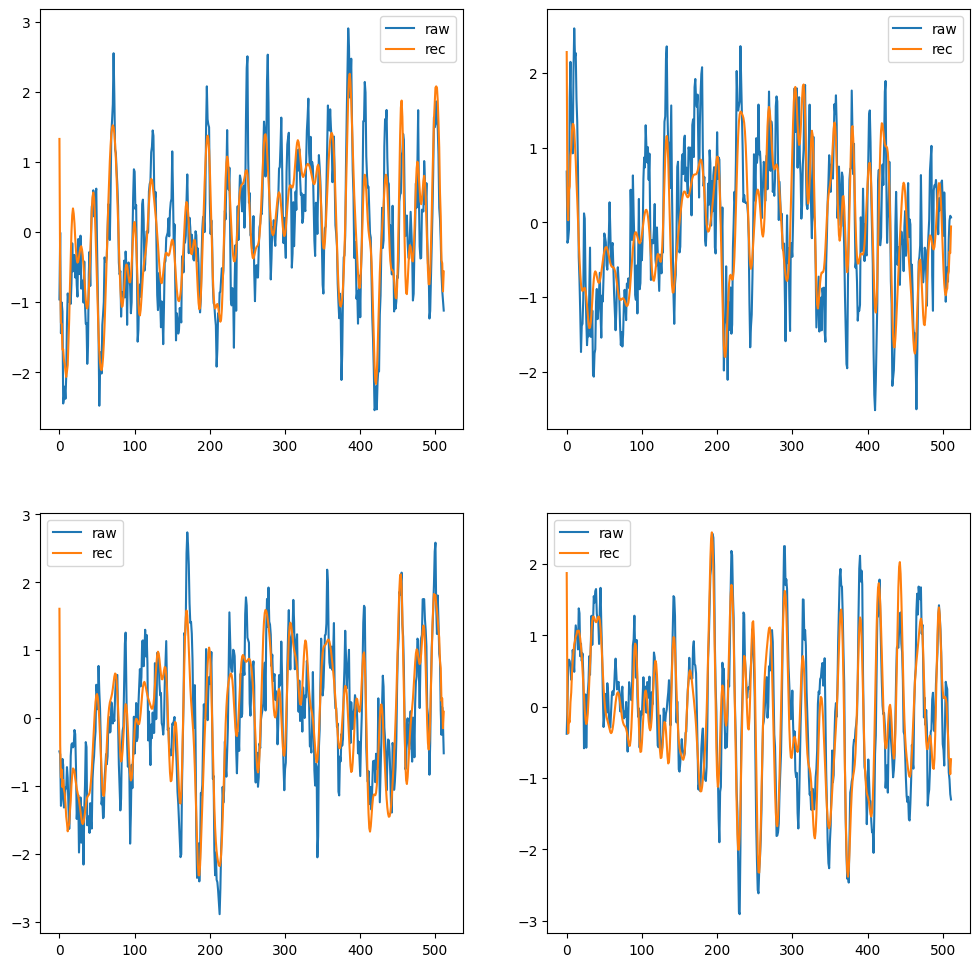

In [9]:
# reconstruction
from einops import rearrange
output_dict=tokenizer.visualize(x,pos,sensor_type)
raw=rearrange(output_dict['x'], "... D -> (...) D")
rec=rearrange(output_dict['x_rec'], "... D -> (...) D")
random_select_indices = torch.randperm(raw.shape[0])[:4]
# randomly choose some to show
plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(raw[random_select_indices[i]], label="raw")
    plt.plot(rec[random_select_indices[i]], label="rec")
    plt.legend()